## Task 1: Data Preparation and Feature Scaling

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
import time
housing_data = fetch_california_housing()
x = housing_data.data
y = housing_data.target
np.random.seed(42)
total_rows = len(x)
shuffle = np.random.permutation(total_rows)
train_size = int(0.6 * total_rows)
validation_size = int(0.2 * total_rows)
train_indexes = shuffle[:train_size]
validation_indexes = shuffle[train_size:train_size + validation_size]
test_indexes = shuffle[train_size + validation_size:]

x_train = x[train_indexes]
y_train = y[train_indexes]

x_validation = x[validation_indexes]
y_validation = y[validation_indexes]

x_test = x[test_indexes]
y_test = y[test_indexes]

train_mean = x_train.mean(axis=0)
train_std = x_train.std(axis=0)
print(train_mean)
print(train_std)

x_train_standardise = (x_train - train_mean) / train_std
x_validation_standardise = (x_validation - train_mean) / train_std
x_test_standardise = (x_test - train_mean) / train_std

train_mean_standardise = x_train_standardise.mean(axis=0)
train_std_standardise = x_train_standardise.std(axis=0)
print(train_mean_standardise)
print(train_std_standardise)


[ 3.87153299e+00  2.86998547e+01  5.41819641e+00  1.09348304e+00
  1.41329215e+03  2.96922784e+00  3.56103464e+01 -1.19555670e+02]
[1.89180693e+00 1.26428318e+01 2.32987480e+00 4.65910192e-01
 1.11502398e+03 2.44606531e+00 2.13016797e+00 1.99750687e+00]
[-7.32501556e-16  1.89788610e-17  6.83330886e-15 -9.69212534e-15
 -9.61606082e-17 -9.62836525e-16  3.33174487e-16 -1.06074028e-13]
[1. 1. 1. 1. 1. 1. 1. 1.]


here we can see that mean are near to zero and standardeviation is 1

##Task 2: Effect of Feature Scaling on Gradient Descent

In [62]:
def add_intercept(X):
    return np.hstack([np.ones((X.shape[0], 1)), X])

def calculate_cost(x, y, theta):
    prediction = x @ theta
    error = prediction - y
    cost = np.sum(error ** 2) / (2 * len(y))
    return cost

def batch_gradient_descent(X, y, alpha, ephochs, theta_init, tol=1e-8):
    X_b = add_intercept(X)
    n = len(y)
    theta = theta_init.copy()
    cost_history = []
    for it in range(ephochs):
        errors = X_b.dot(theta) - y
        gradient = (1 / n) * X_b.T.dot(errors)
        theta = theta - alpha * gradient
        cost = calculate_cost(X_b, y, theta)
        if not np.isfinite(cost):
            break
        cost_history.append(cost)
        if it > 0 and abs(cost_history[-2] - cost_history[-1]) < tol:
            break
    return theta, cost_history

d = x_train.shape[1]
theta_init = np.zeros(d + 1)
ephochs = 20000
alpha_unscaled_7 = 1e-7
start = time.time()
theta_unscaled_7, cost_hist_unscaled_7 = batch_gradient_descent(x_train, y_train, alpha_unscaled_7, ephochs, theta_init)
time_unscaled_7 = time.time() - start
alpha_unscaled_6 = 1e-6
start = time.time()
theta_unscaled_6, cost_hist_unscaled_6 = batch_gradient_descent(x_train, y_train, alpha_unscaled_6, ephochs, theta_init)
time_unscaled_6 = time.time() - start
alpha_scaled = 0.1
start = time.time()
theta_scaled, cost_hist_scaled = batch_gradient_descent(x_train_standardise, y_train, alpha_scaled, ephochs, theta_init)
time_scaled = time.time() - start

print("=== Unscaled features ===")
print(f"Learning rate      : {alpha_unscaled_6}")
print(f"Iterations run     : {len(cost_hist_unscaled_6)}")
print(f"Final training cost: {cost_hist_unscaled_6[-1]:.6f}")
print(f"Execution time (s) : {time_unscaled_6:.4f}")
print("=== Unscaled features ===")
print(f"Learning rate      : {alpha_unscaled_7}")
print(f"Iterations run     : {len(cost_hist_unscaled_7)}")
print(f"Final training cost: {cost_hist_unscaled_7[-1]:.6f}")
print(f"Execution time (s) : {time_unscaled_7:.4f}")

print("\n=== Scaled features ===")
print(f"Learning rate      : {alpha_scaled}")
print(f"Iterations run     : {len(cost_hist_scaled)}")
print(f"Final training cost: {cost_hist_scaled[-1]:.6f}")
print(f"Execution time (s) : {time_scaled:.4f}")

=== Unscaled features ===
Learning rate      : 1e-06
Iterations run     : 431
Final training cost: 6454329570267418915717252900196907524090644913987417622083787273730064090008603365890515043704721650054478570226597718567698165707929118176109071521354344327974587211554392890732946166624702014746585173490836246502825807392756292263315678859611846206247798115345465740939234360843035067468324032114327552.000000
Execution time (s) : 0.0621
=== Unscaled features ===
Learning rate      : 1e-07
Iterations run     : 20000
Final training cost: 0.651971
Execution time (s) : 3.0723

=== Scaled features ===
Learning rate      : 0.1
Iterations run     : 990
Final training cost: 0.260710
Execution time (s) : 0.1654


Feature scaling makes Gradient Descent converge faster. In the unscaled data, 1e-6 was too large and gave NaN, so we used 1e-7 for stable training. Even then, it took all 20,000 iterations. After scaling the features, we could use a larger learning rate of 0.1, and the model converged in only 990 iterations. This shows that scaling the features makes Gradient Descent more stable and much faster. Therefore, we will use the scaled features for the remaining tasks

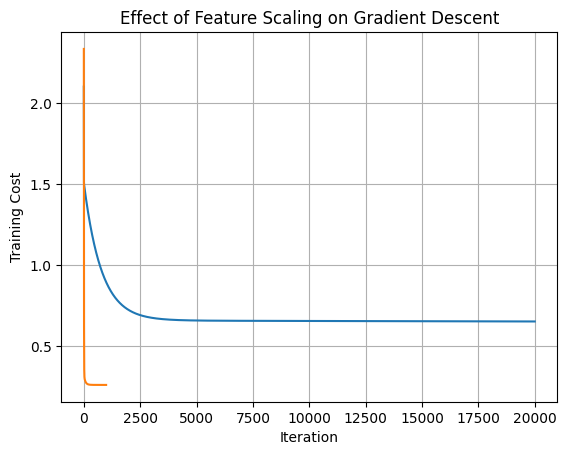

In [63]:
plt.plot(cost_hist_unscaled_7,label="Unscaled (alpha = 1e-7)")
plt.plot(cost_hist_scaled,label="Scaled (alpha = 0.1)")
plt.xlabel("Iteration")
plt.ylabel("Training Cost")
plt.title("Effect of Feature Scaling on Gradient Descent")
plt.grid(True)
plt.show()

##Task 3: Ridge Regression using Gradient Descent

In [64]:
def ridge_cost(x, y, theta, lambda_reg):
    n = len(y)
    predictions = x @ theta
    errors = predictions - y
    cost = (1 / (2 * n)) * np.sum(errors ** 2)
    regularization = (lambda_reg / (2 * n)) * np.sum(theta[1:] ** 2)
    return cost + regularization

def ridge_gradient_descent(x,y,alpha,lambda_reg,epochs,theta_init,tol=1e-8):
    x = add_intercept(x)
    n = len(y)
    theta = theta_init.copy()
    cost_history = []
    for it in range(epochs):
        predictions = x @ theta
        errors = predictions - y
        gradient = (1 / n) * (x.T @ errors)
        reg_gradient = (lambda_reg / n) * theta
        reg_gradient[0] = 0
        gradient = gradient + reg_gradient
        theta = theta - alpha * gradient
        cost = ridge_cost(x, y, theta, lambda_reg)
        if not np.isfinite(cost):
            break
        cost_history.append(cost)
        if (it > 0 and abs(cost_history[-2] - cost_history[-1]) < tol):
            break
    return theta, cost_history

In [65]:
alpha = 0.1
lambda_reg = 0
epochs = 20000
theta_init = np.zeros(x_train_standardise.shape[1] + 1)
start = time.time()
theta_linear, cost_hist_linear = batch_gradient_descent(x_train_standardise,y_train,alpha,epochs,theta_init)
time_linear = time.time() - start

start = time.time()
theta_ridge_0, cost_hist_ridge_0 = ridge_gradient_descent(x_train_standardise,y_train,alpha,lambda_reg,epochs,theta_init)
time_ridge_0 = time.time() - start

print("\nOrdinary Linear Regression")
print(f"Iterations       : {len(cost_hist_linear)}")
print(f"Final cost       : {cost_hist_linear[-1]:.10f}")
print(f"Execution time   : {time_linear:.4f} seconds")

print("\nRidge Regression (lambda = 0)")
print(f"Iterations       : {len(cost_hist_ridge_0)}")
print(f"Final cost       : {cost_hist_ridge_0[-1]:.10f}")
print(f"Execution time   : {time_ridge_0:.4f} seconds")

print("\nDifference between parameter vectors:")
print(np.linalg.norm(theta_linear - theta_ridge_0))

print("\nDifference between final costs:")
print(abs(cost_hist_linear[-1] - cost_hist_ridge_0[-1]))


Ordinary Linear Regression
Iterations       : 990
Final cost       : 0.2607097661
Execution time   : 0.1625 seconds

Ridge Regression (lambda = 0)
Iterations       : 990
Final cost       : 0.2607097661
Execution time   : 0.1635 seconds

Difference between parameter vectors:
0.0

Difference between final costs:
0.0


When λ = 0, Ridge Regression gave the same parameters and final cost as Linear Regression. The difference was 0.0. This shows that when λ is 0, there is no regularization, so Ridge Regression works the same as normal Linear Regression.

## Task 4: Significance and Visualization of Regularization

A. Effect of λ on the Regression Model
Using all scaled input features, train the Ridge Regression model for

λ ∈ {0, 0.01, 0.1, 1, 10, 100} .



In [66]:
lambdas = [0, 0.01, 0.1, 1, 10, 100]
alpha = 0.1
epochs = 20000
theta_init = np.zeros(x_train_standardise.shape[1] + 1)
results = []
def l2_norm_manual(vector):
    total = 0
    for value in vector:
        total = total + value ** 2
    return total ** 0.5
for lam in lambdas:
    theta_new, cost_history_l = ridge_gradient_descent(x_train_standardise, y_train, alpha, lam, epochs, theta_init)
    x_train_b = add_intercept(x_train_standardise)
    x_val_b   = add_intercept(x_validation_standardise)
    train_mse = np.mean((x_train_b @ theta_new - y_train) ** 2)
    val_mse   = np.mean((x_val_b   @ theta_new - y_validation)   ** 2)
    theta_magnitude = l2_norm_manual(theta_new[1:])
    results.append({
        "lambda": lam,
        "theta": theta_new,
        "train_mse": train_mse,
        "val_mse": val_mse,
        "theta_magnitude": theta_magnitude
    })
    print(f"lambda={lam:<7} train_mse={train_mse:.5f}  val_mse={val_mse:.5f} theta={theta_magnitude:.5f}")

lambda=0       train_mse=0.52142  val_mse=0.90713 theta=1.54292
lambda=0.01    train_mse=0.52142  val_mse=0.90713 theta=1.54291
lambda=0.1     train_mse=0.52142  val_mse=0.90714 theta=1.54279
lambda=1       train_mse=0.52142  val_mse=0.90722 theta=1.54165
lambda=10      train_mse=0.52144  val_mse=0.90803 theta=1.53039
lambda=100     train_mse=0.52275  val_mse=0.91633 theta=1.43104


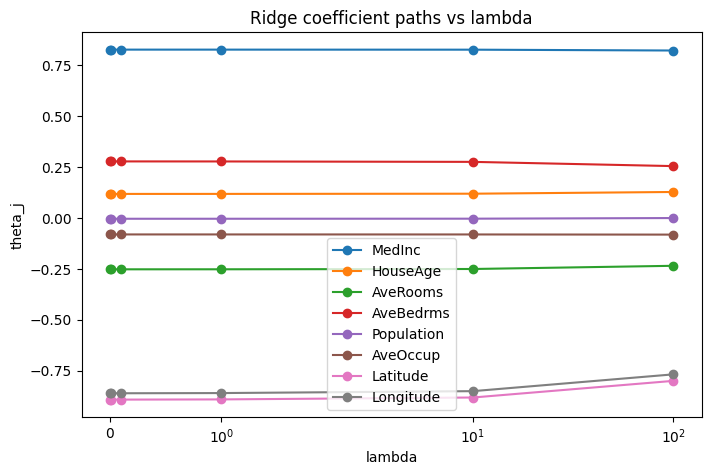

In [67]:
plt.figure(figsize=(8,5))
for j, name in enumerate(housing_data.feature_names):
    coef_path = [r["theta"][1 + j] for r in results]   # theta[j+1] because index 0 is the intercept
    plt.plot(lambdas, coef_path, marker='o', label=name)
plt.xscale('symlog')   # lambda includes 0, so a normal log scale would fail — symlog handles 0 gracefully
plt.xlabel("lambda")
plt.ylabel("theta_j")
plt.title("Ridge coefficient paths vs lambda")
plt.legend()
plt.show()

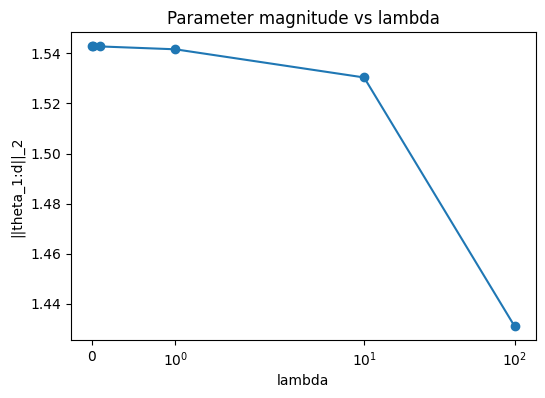

In [68]:
plt.figure(figsize=(6,4))
norms = [r["theta_magnitude"] for r in results]
plt.plot(lambdas, norms, marker='o')
plt.xscale('symlog')
plt.xlabel("lambda")
plt.ylabel("||theta_1:d||_2")
plt.title("Parameter magnitude vs lambda")
plt.show()

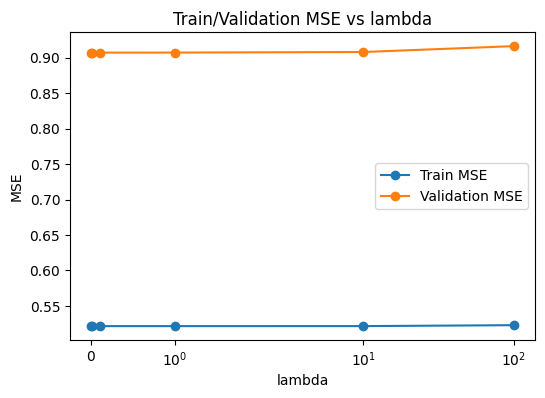

In [69]:
plt.figure(figsize=(6,4))
train_mses = [r["train_mse"] for r in results]
val_mses   = [r["val_mse"]   for r in results]
plt.plot(lambdas, train_mses, marker='o', label="Train MSE")
plt.plot(lambdas, val_mses,   marker='o', label="Validation MSE")
plt.xscale('symlog')
plt.xlabel("lambda")
plt.ylabel("MSE")
plt.legend()
plt.title("Train/Validation MSE vs lambda")
plt.show()

As λ increases from 0 to 100, the parameter magnitude decreases from 1.543 to 1.431. This shows that Ridge Regression reduces the size of the model parameters as the regularization becomes stronger.

The training MSE increases slightly from 0.5214 to 0.5228. The validation MSE also increases from 0.9071 to 0.9163. In this case, λ = 0 gives the lowest validation MSE, so the model does not seem to have much overfitting.

## B. Visualization of the Regularized Cost Function

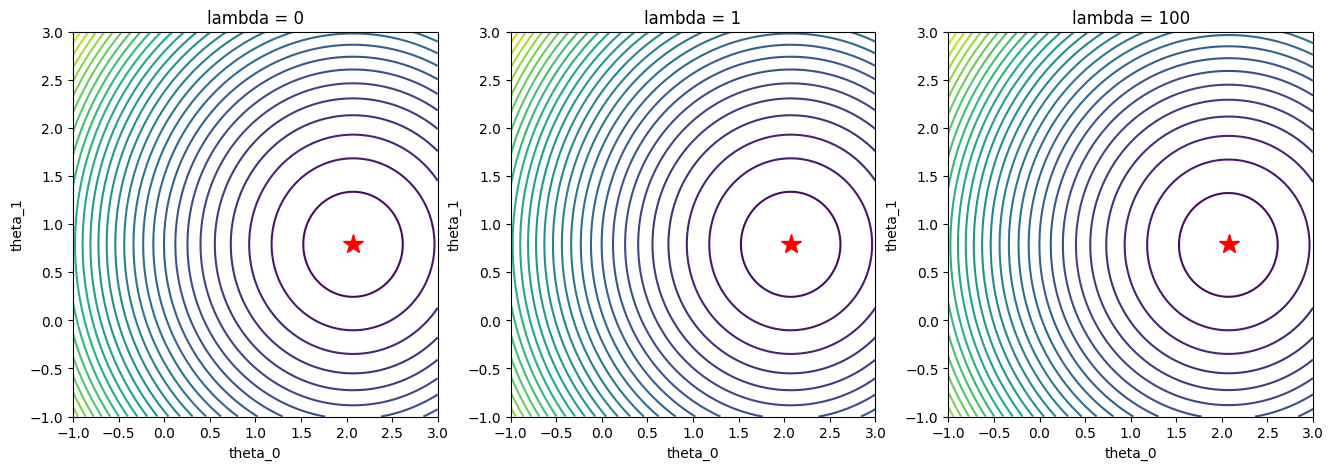

In [70]:
medinc_idx = list(housing_data.feature_names).index("MedInc")
x_mi = x_train_standardise[:, medinc_idx]   # just the MedInc column
y_mi = y_train
def ridge_cost_1d(theta0, theta1, x, y, lam):
    n = len(y)
    predictions = theta0 + theta1 * x
    errors = predictions - y
    return (1/(2*n)) * (np.sum(errors**2) + lam * theta1**2)
theta0_vals = np.linspace(-1, 3, 200)
theta1_vals = np.linspace(-1, 3, 200)
T0, T1 = np.meshgrid(theta0_vals, theta1_vals)
lambdas_contour = [0, 1, 100]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, lam in zip(axes, lambdas_contour):
    Z = np.zeros_like(T0)
    for i in range(T0.shape[0]):
        for j in range(T0.shape[1]):
            Z[i, j] = ridge_cost_1d(T0[i, j], T1[i, j], x_mi, y_mi, lam)
    cp = ax.contour(T0, T1, Z, levels=30)
    ax.set_xlabel("theta_0")
    ax.set_ylabel("theta_1")
    ax.set_title(f"lambda = {lam}")
    min_idx = np.unravel_index(np.argmin(Z), Z.shape)
    ax.plot(T0[min_idx], T1[min_idx], 'r*', markersize=15)
plt.show()

For λ = 0, 1, and 100, the minimum point of the cost function does not change much. This is because the dataset has a large number of training samples, so even λ = 100 has only a small effect on the model. Therefore, the change in the cost function is not very noticeable in the plots. This is also similar to the small change in the parameter magnitude that we saw in Task 4A.

## Task 5: Ridge Regression using the Normal Equation

In [71]:
def ridge_normal_equation(X, y, lam):
    X_b = add_intercept(X)
    d1 = X_b.shape[1]
    R = np.eye(d1)
    R[0, 0] = 0
    theta = np.linalg.solve(X_b.T @ X_b + lam * R, X_b.T @ y)
    return theta

def l2_norm_manual(vector):
    total = 0
    for value in vector:
        total = total + value ** 2
    return total ** 0.5
def mse_manual(X, y, theta):
    X_b = add_intercept(X)
    predictions = X_b @ theta
    errors = predictions - y
    total = 0
    for e in errors:
        total = total + e ** 2
    return total / len(y)

lam_compare = 1.0
alpha = 0.1
epochs = 20000
theta_init = np.zeros(x_train_standardise.shape[1] + 1)

start = time.time()
theta_gd, cost_hist_gd = ridge_gradient_descent(x_train_standardise, y_train, alpha, lam_compare, epochs, theta_init)
time_gd = time.time() - start

start = time.time()
theta_ne = ridge_normal_equation(x_train_standardise, y_train, lam_compare)
time_ne = time.time() - start


train_mse = mse_manual(x_train_standardise, y_train, theta_gd)
val_mse   = mse_manual(x_validation_standardise, y_validation, theta_gd)
test_mse  = mse_manual(x_test_standardise, y_test, theta_gd)

print(f"Train MSE gd : {train_mse:.5f}")
print(f"Validation MSE gd : {val_mse:.5f}")
print(f"Test MSE gd : {test_mse:.5f}")
print(f"Execution time gd : {time_gd:.6f} seconds\n")

train_mse = mse_manual(x_train_standardise, y_train, theta_ne)
val_mse   = mse_manual(x_validation_standardise, y_validation, theta_ne)
test_mse  = mse_manual(x_test_standardise, y_test, theta_ne)

print(f"Train MSE ne: {train_mse:.5f}")
print(f"Validation MSE ne : {val_mse:.5f}")
print(f"Test MSE ne: {test_mse:.5f}")
print(f"Execution time ne : {time_ne:.6f} seconds\n")

theta_diff = l2_norm_manual(theta_gd - theta_ne)
print(f"||theta_GD - theta_NE||_2 = {theta_diff:.6f}")

theta_ne_lam0 = ridge_normal_equation(x_train_standardise, y_train, lam=0.0)
diff_check = l2_norm_manual(theta_ne_lam0 - theta_linear)
print(f"\n||theta_NE(lambda=0) - theta_plain_OLS||_2 = {diff_check:.6f}")

Train MSE gd : 0.52142
Validation MSE gd : 0.90722
Test MSE gd : 0.61638
Execution time gd : 0.173642 seconds

Train MSE ne: 0.52142
Validation MSE ne : 0.90757
Test MSE ne: 0.61622
Execution time ne : 0.000876 seconds

||theta_GD - theta_NE||_2 = 0.007089

||theta_NE(lambda=0) - theta_plain_OLS||_2 = 0.007096


Gradient Descent and the Normal Equation gave almost the same results. The training MSE was the same, and the validation and test MSE were also very close. The difference between the parameters was very small, which means both methods reached almost the same solution.

The main difference was the execution time. The Normal Equation was much faster than Gradient Descent because there were only 8 features, so solving the small matrix was quick. Gradient Descent needed many iterations to reach the minimum.

Overall, for this dataset with a small number of features, the Normal Equation is faster and gives a direct solution. Gradient Descent is still useful when the number of features or the dataset size is very large.